
**Procesamiento de Imágenes   ITSE - Instituto Tecnológico de Santiago del Estero**


# Introduction Example for Color Segmentation



# Libraries

In [1]:
import numpy as np
from  cv2 import imread
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# How is the image?

In [2]:
def howis(img):
  print('size = ',img.shape)
  print('max  = ',np.max(img))
  print('min  = ',np.min(img))

# Reading the color image

In [3]:
REPO = 'https://raw.githubusercontent.com/domingomery/pr/main/clases/'
!wget {REPO}PR02_Extraccion_de_Caracteristicas/datos/flowers.jpg

--2026-08-24 00:56:21--  https://raw.githubusercontent.com/domingomery/pr/main/clases/PR02_Extraccion_de_Caracteristicas/datos/flowers.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983616 (961K) [image/jpeg]
Saving to: ‘flowers.jpg’

flowers.jpg         100%[===================>] 960.56K  --.-KB/s    in 0.009s  

2026-08-24 00:56:23 (106 MB/s) - ‘flowers.jpg’ saved [983616/983616]



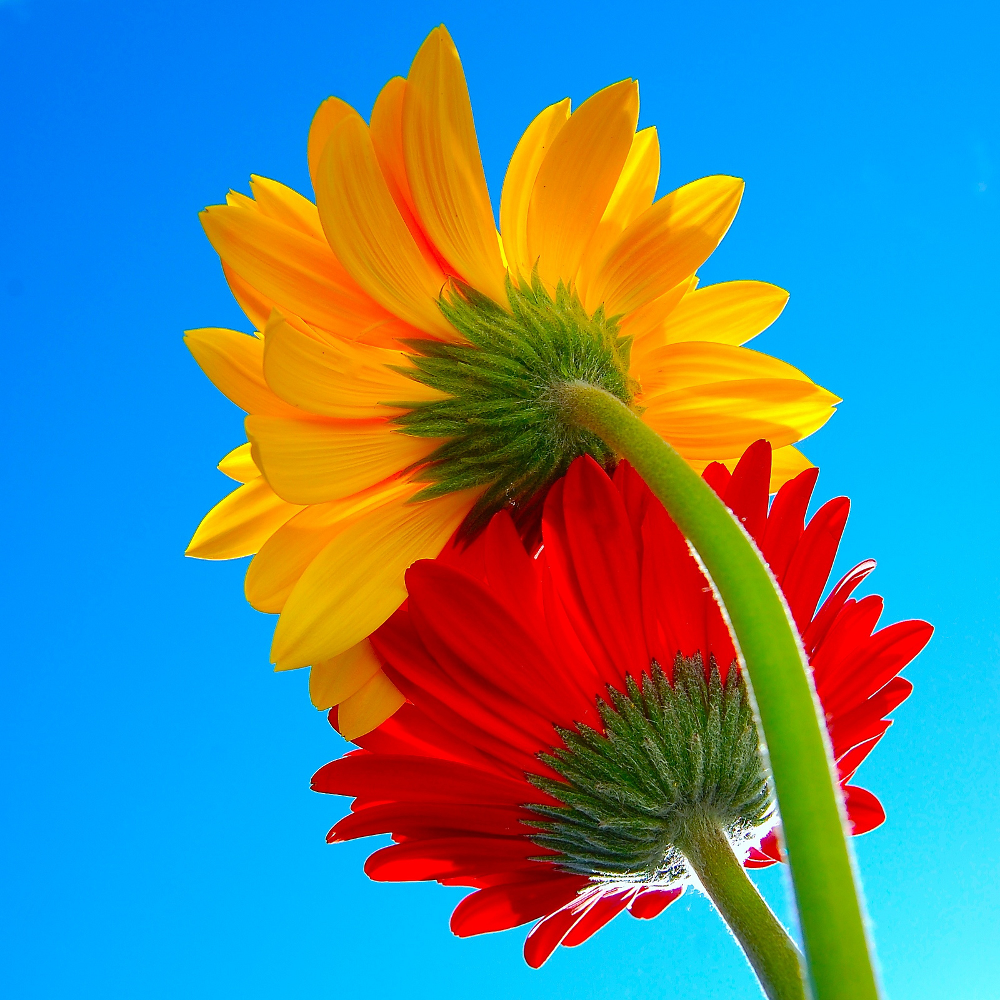

size =  (1600, 1600, 3)
max  =  255
min  =  0


In [4]:
Icv = imread('flowers.jpg')      # opencv format (BGR)
cv2_imshow(Icv)
howis(Icv)

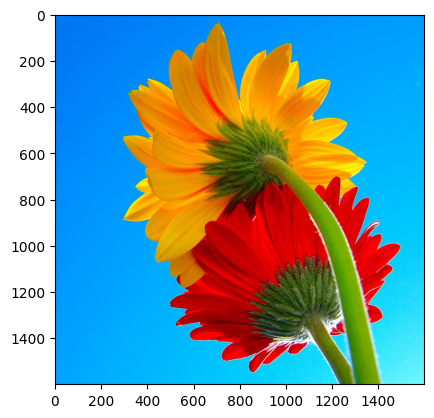

In [5]:
I = Icv[:,:,[2,1,0]]             # BGR to RGB conversion
plt.imshow(I)
plt.show()

# Color channels

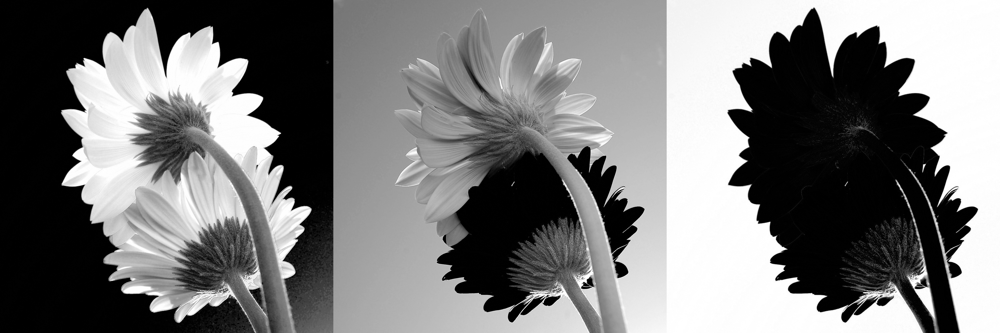

In [6]:
R = I[:,:,0]
G = I[:,:,1]
B = I[:,:,2]
RGB = np.concatenate((R,G,B),axis=1)
cv2_imshow(RGB)

# Conversion a blanco y negro (tonos de gris)

size =  (1600, 1600)
max  =  255
min  =  0


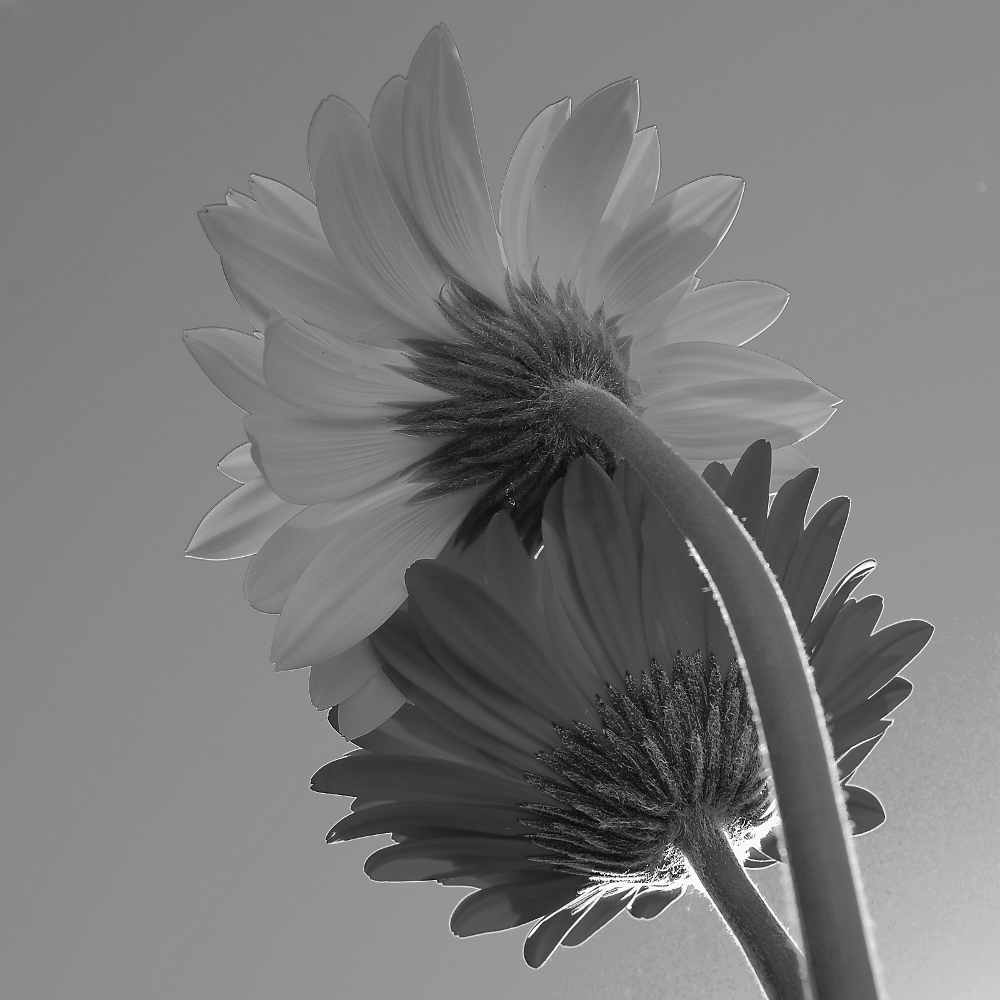

In [7]:
Rd = R.astype(float)
Gd = G.astype(float)
Bd = B.astype(float)
# weighted average
k  = (1/3,1/3,1/3)
#k  = (0.1,0.4,0.5)
Zd = k[0]*Rd+k[1]*Gd+k[2]*Bd
Z  = Zd.astype(int)
howis(Z)
cv2_imshow(Z)

# Histogram

In [8]:
def imhist(X):
  (N,M) = X.shape
  n = 256
  h = np.zeros((256,))
  for i in range(N):
    for j in range(M):
      x = X[i,j]
      h[x] = h[x]+1
  plt.plot(range(n),h[0:n])
  plt.show()


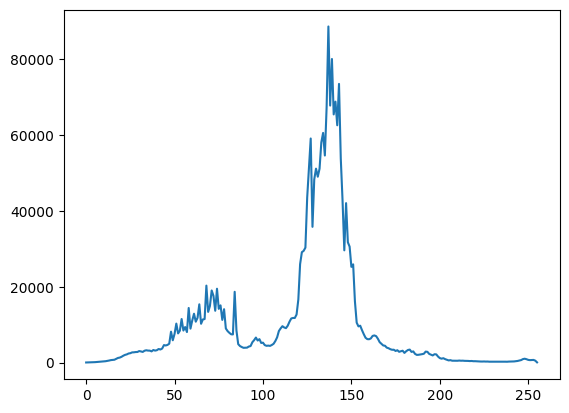

In [9]:
imhist(Z)

# Segmentation of the red flower

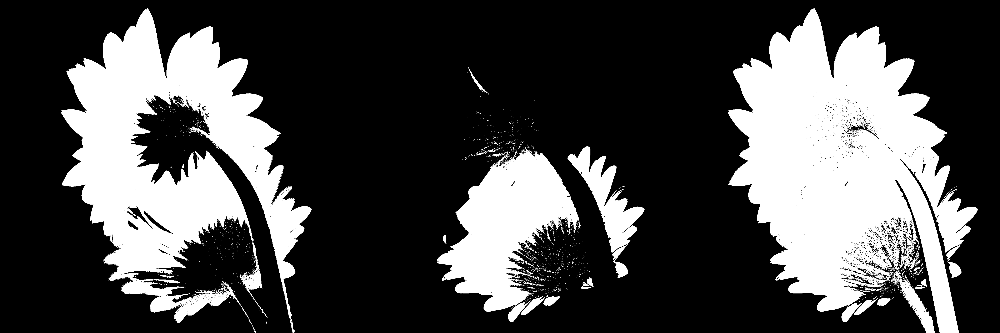

In [10]:
Sr = R>150
Sg = G<40
Sb = B<40
#print(np.max(Sr))
Srgb = np.concatenate((Sr,Sg,Sb),axis=1)
cv2_imshow(Srgb*255)

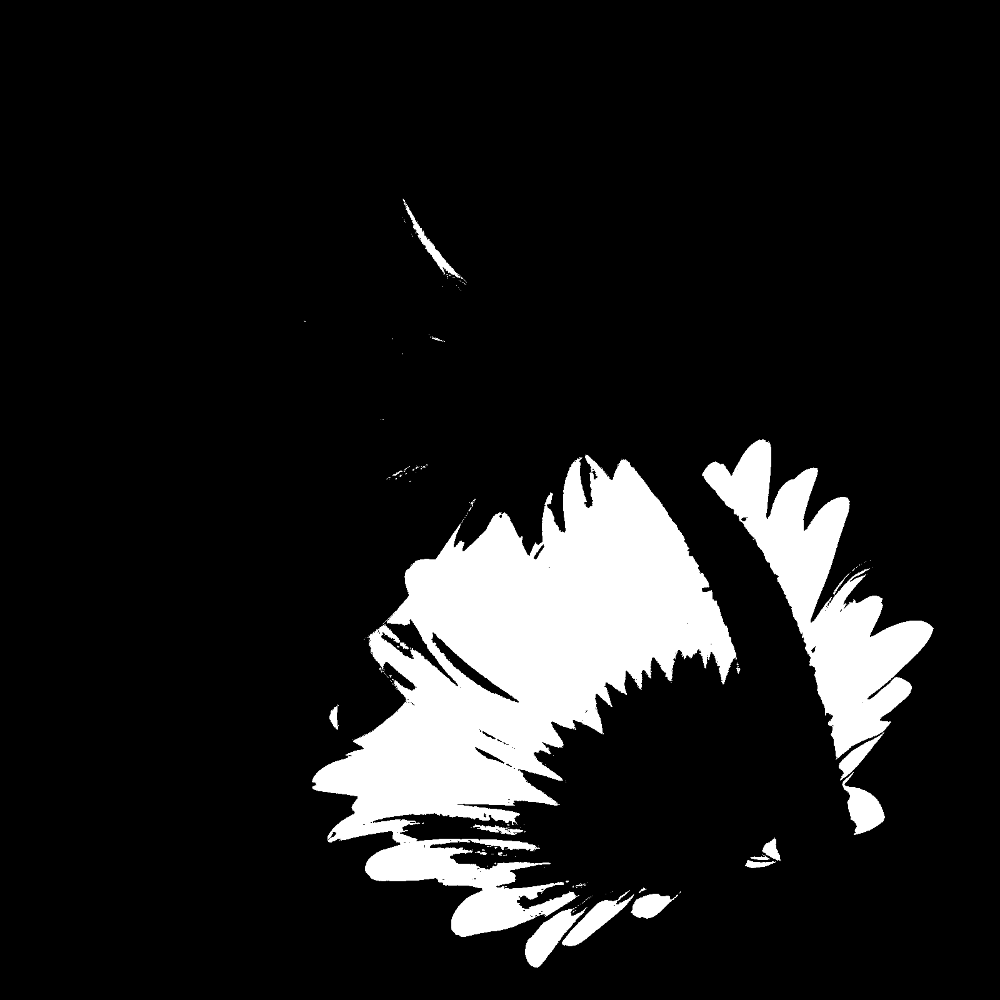

In [11]:
Srg = np.logical_and(Sr,Sg)
S   = np.logical_and(Srg,Sb)
cv2_imshow(S*255)

# Removing isolated pixels

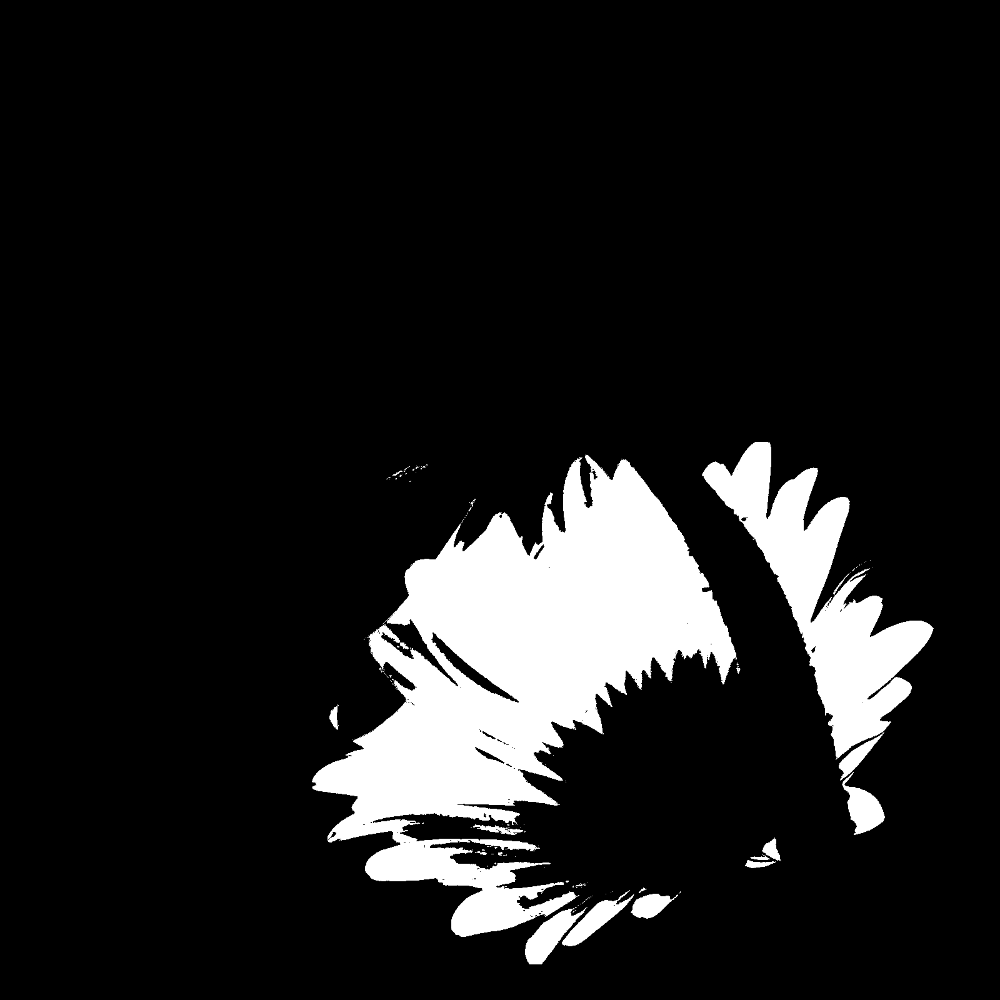

In [12]:
(N,M) = S.shape
Q = S
for i in range(N):
  s = np.sum(S[i,:])
  if s<20:
    Q[i,:] = 0
cv2_imshow(Q*255)

# Searching (imin,jmin) and (imax,jmax) in the segmented region

In [13]:
imin = 1000
imax = 0
jmin = 1000
jmax = 0
for i in range(N):
  for j in range(M):
    if Q[i,j]>0:
      if i<imin:
        imin = i
      if i>imax:
        imax = i
      if j<jmin:
        jmin = j
      if j>jmax:
        jmax = j

# Bounding Box

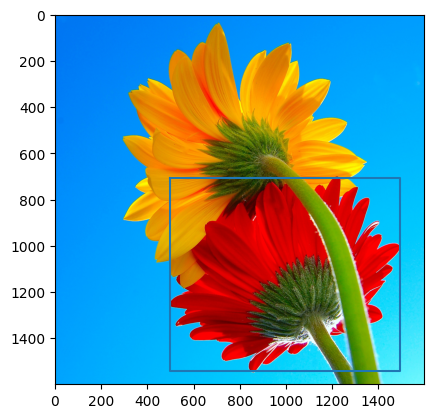

In [14]:
y = [imin,imin,imax,imax,imin]
x = [jmin,jmax,jmax,jmin,jmin]
plt.imshow(I)
plt.plot(x,y)
plt.show()

# Edge detection

In [ ]:
E = np.zeros((N,M),np.uint8)
for i in range(N):
  for j in range(1,M):
    if Q[i,j]!=Q[i,j-1]:
      E[i,j]   = 1
      E[i,j-1] = 1
for i in range(1,N):
  for j in range(M):
    if Q[i-1,j]!=Q[i,j]:
      E[i,j]   = 1
      E[i,j-1] = 1
cv2_imshow(E*255)


In [ ]:
for i in range(N):
  for j in range(M):
    if E[i,j]==1:
      Icv[i,j,:] = [255,0,0]
cv2_imshow(Icv)

In [ ]:
import cv2

# Segmentation of the green stems

In [ ]:
Ihsv = cv2.cvtColor(Icv, cv2.COLOR_BGR2HSV)

H = Ihsv[:,:,0]
S_channel = Ihsv[:,:,1]
V = Ihsv[:,:,2]

Svr = (H > 35) & (H < 85)
Svg = (S_channel > 40)
Svb = (V > 40)
Sv  = Svr & Svg & Svb

print('HSV - Verde segmentado:', np.sum(Sv), 'pixels (', round(100*np.sum(Sv)/(N*M),2), '% )')
cv2_imshow(Sv * 255)

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
Sv_clean = cv2.morphologyEx(Sv.astype(np.uint8), cv2.MORPH_OPEN, kernel, iterations=2)
Sv_clean = cv2.morphologyEx(Sv_clean, cv2.MORPH_CLOSE, kernel, iterations=2)

print('Antes de limpiar:', np.sum(Sv), 'pixels')
print('Después de limpiar:', np.sum(Sv_clean), 'pixels')
cv2_imshow(Sv_clean * 255)

In [ ]:
num_labels, labels = cv2.connectedComponents(Sv_clean)

print('Tallos encontrados:', num_labels - 1)

colores = [
    [255,0,0], [0,255,0], [0,0,255], [255,255,0],
    [255,0,255], [0,255,255], [128,0,0], [0,128,0]
]

Istems = Icv.copy()
for k in range(1, num_labels):
    mask_k = (labels == k)
    area = np.sum(mask_k)
    if area > 100:
        for c in range(3):
            Istems[:,:,c] = np.where(mask_k, colores[(k-1) % len(colores)][c], Istems[:,:,c])

cv2_imshow(Istems)

In [ ]:
Ibbox = Icv.copy()
areas = []

for k in range(1, num_labels):
    mask_k = (labels == k)
    area = np.sum(mask_k)
    if area > 100:
        indices = np.where(mask_k)
        imin_k = np.min(indices[0])
        imax_k = np.max(indices[0])
        jmin_k = np.min(indices[1])
        jmax_k = np.max(indices[1])
        areas.append(area)
        cv2.rectangle(Ibbox, (jmin_k, imin_k), (jmax_k, imax_k), (0, 255, 0), 2)

print('Tallos significativos:', len(areas))
for idx, a in enumerate(areas):
    print(f'  Tallo {idx+1}: {a} pixels')

cv2_imshow(Ibbox)

In [ ]:
Ev = np.zeros((N, M), np.uint8)
for i in range(N):
    for j in range(1, M):
        if Sv_clean[i, j] != Sv_clean[i, j-1]:
            Ev[i, j]   = 1
            Ev[i, j-1] = 1
for i in range(1, N):
    for j in range(M):
        if Sv_clean[i-1, j] != Sv_clean[i, j]:
            Ev[i, j]   = 1
            Ev[i, j-1] = 1

Iresult = Icv.copy()
for i in range(N):
    for j in range(M):
        if Ev[i, j] == 1:
            Iresult[i, j, :] = [0, 255, 0]

cv2_imshow(Iresult)

In [ ]:
R_v = Sv_clean.astype(np.uint8) * 255
G_v = Sv_clean.astype(np.uint8) * 255
B_v = Sv_clean.astype(np.uint8) * 255
Mask_rgb = np.stack([R_v, G_v, B_v], axis=2)

Ioverlay = Icv.copy()
for c in range(3):
    Ioverlay[:,:,c] = np.where(Sv_clean, Icv[:,:,c]//2 + Mask_rgb[:,:,c]//2, Icv[:,:,c])

comparativa = np.concatenate((Icv, Ioverlay, Iresult), axis=1)
cv2_imshow(comparativa)

**EJERCICIO**
Realice una segmentación de los tallos de las flores (todo lo verde)

**Bibliografía**  
D. Mery. Fundamentos de Procesamiento de Imágenes Departamento de Ciencia de la Computación. Universidad Católica de Chile, 2024.